# Modelado Farmacocinético Poblacional de Concentración-Tiempo con PROC NLMIXED

## Resumen ejecutivo

Este cuaderno ajusta un modelo farmacocinético (FC) poblacional de un compartimento con absorción de primer orden a datos simulados de concentración plasmática en función del tiempo, provenientes de un estudio de dosis única por vía oral. Usando PROC NLMIXED, estimamos los parámetros poblacionales de efectos fijos (aclaramiento aparente CL/F, tasa de absorción ka, tasa de eliminación ke) junto con un efecto aleatorio entre sujetos sobre el log-aclaramiento, la principal fuente de variabilidad farmacocinética en la mayoría de las poblaciones. Luego retransformamos los efectos fijos en escala logarítmica a magnitudes farmacocinéticas interpretables (aclaramiento, vida media) y comparamos las concentraciones observadas con las predichas a nivel poblacional para confirmar que el modelo estructural capta tanto la fase de absorción como la de eliminación.

## Fuentes de datos

| Conjunto de datos | Descripción | Filas | Variables clave |
| ------- | ----------- | ---: | ------------- |
| `pk` | Estudio FC sintético de dosis única por vía oral: 10 sujetos, 7 tiempos de muestreo nominales cada uno (0.25-12 h), generado a partir de un modelo de un compartimento con absorción de primer orden con variabilidad entre sujetos en el aclaramiento más error residual aditivo | 70 | `subject` (1-10), `time` (h tras la dosis), `conc` (concentración plasmática, mg/L), `dose` (mg/kg), `wt` (peso corporal, kg) |

## 1. Simular el estudio FC poblacional

El análisis farmacocinético poblacional describe cómo evoluciona la concentración del fármaco en el tiempo a través de un grupo de sujetos, teniendo en cuenta la variabilidad entre individuos. Modelamos una única dosis oral con una estructura de **un compartimento con absorción de primer orden**, cuya concentración predicha en el tiempo *t* es

$$ C(t) = \frac{D \cdot k_e \cdot k_a}{CL\,(k_a - k_e)}\,\bigl(e^{-k_e t} - e^{-k_a t}\bigr) $$

donde `CL` es el aclaramiento aparente, `ka` la constante de tasa de absorción y `ke` la constante de tasa de eliminación. El DATA step siguiente genera un ensayo compacto: 10 sujetos, cada uno muestreado en 7 tiempos nominales. El aclaramiento a nivel de sujeto varía log-normalmente (variabilidad entre sujetos), y cada concentración observada lleva un error de medición aditivo. Los parámetros se simulan en la escala logarítmica para que las constantes de tasa permanezcan positivas.

In [1]:
/* --------------------------------------------------------
   Simular un estudio FC poblacional de dosis única por vía oral
   Modelo de un compartimento con absorción de primer orden
   10 sujetos x 7 tiempos de muestreo = 70 observaciones
   -------------------------------------------------------- */
DATOS pk;
    LLAMAR streaminit(20260531);

    /* Parámetros poblacionales verdaderos en la escala logarítmica */
    beta1 = -3.22;   /* log aclaramiento aparente CL/F              */
    beta2 =  0.47;   /* log constante de tasa de absorción ka (1/h) */
    beta3 = -2.45;   /* log constante de tasa de eliminación ke (1/h)*/

    /* Variabilidad entre sujetos y error residual */
    sd_b1 = 0.25;    /* DE del log CL (entre sujetos)                */
    sigma = 0.40;    /* DE residual de la concentración (mg/L)       */

    HACER subject = 1 HASTA 10;
        wt   = round(rand('normal', 70, 9), 0.1);
        dose = round(4.5 + rand('uniform') * 1.6, 0.01);

        /* Desviación aleatoria específica del sujeto en el log CL */
        b1 = rand('normal', 0, sd_b1);

        cl = exp(beta1 + b1);
        ka = exp(beta2);
        ke = exp(beta3);

        HACER _t = 1 HASTA 7;
            SELECCIONAR (_t);
                CUANDO (1) time = 0.25;
                CUANDO (2) time = 0.50;
                CUANDO (3) time = 1.00;
                CUANDO (4) time = 2.00;
                CUANDO (5) time = 4.00;
                CUANDO (6) time = 7.00;
                CUANDO (7) time = 12.00;
                OTRO time = .;
            END;

            /* Concentración media verdadera según el modelo FC */
            mu   = dose * ke * ka *
                   (exp(-ke*time) - exp(-ka*time)) / cl / (ka - ke);
            conc = mu + rand('normal', 0, sigma);
            SI conc < 0 ENTONCES conc = 0;   /* no negativo */
            SALIDA;
        END;
    END;

    MANTENER subject time conc dose wt;
EJECUTAR;


NOTE: DATA pk


NOTE: Wrote pk (70 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 2. Inspeccionar los perfiles simulados

Antes de modelar, resumimos los datos y observamos el perfil de un sujeto. Los tiempos de muestreo abarcan la fase de absorción (concentraciones en aumento) hasta la fase de eliminación (concentraciones en descenso), lo cual es lo que hace identificables las constantes de tasa de absorción y eliminación.

In [2]:
PROCEDIMIENTO MEDIAS DATOS=pk n mean std MIN MAX maxdec=3;
    VAR time conc dose wt;
    ETIQUETA time='Tiempo tras la dosis (h)' conc='Concentración plasmática (mg/L)'
             dose='Dosis (mg/kg)' wt='Peso corporal (kg)';
    TÍTULO 'Resumen del estudio FC simulado';
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=pk(obs=7) noobs;
    VAR subject time conc dose wt;
    ETIQUETA subject='Sujeto' time='Tiempo tras la dosis (h)' conc='Concentración plasmática (mg/L)'
             dose='Dosis (mg/kg)' wt='Peso corporal (kg)';
    TÍTULO 'Perfil de concentración-tiempo del sujeto 1';
EJECUTAR;
TÍTULO;

                                            Resumen del estudio FC simulado                                             

                                                  The MEANS Procedure

 Variable  Label                                    N           Mean     Std Dev     Minimum     Maximum
 -------------------------------------------------------------------------------------------------------
 time      Tiempo tras la dosis (h)                70          3.821       4.030       0.250      12.000
 conc      Concentración plasmática (mg/L)         70          6.987       2.471       2.931      12.221
 dose      Dosis (mg/kg)                           70          5.245       0.444       4.730       5.990
 wt        Peso corporal (kg)                      70         66.490       8.188      50.600      79.000
 -------------------------------------------------------------------------------------------------------

                                      Perfil de concentración-tiempo de


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=pk

NOTE: PROC PRINT completed: 7 observations printed, 5 variables


## 3. Visualizar los perfiles de concentración-tiempo

Superponer el perfil de cada sujeto muestra la forma farmacocinética característica: un ascenso rápido de absorción hasta una concentración máxima cerca de las dos horas, seguido de un declive exponencial más lento. La dispersión vertical entre sujetos en un tiempo dado es la variabilidad entre sujetos que el efecto aleatorio sobre el aclaramiento cuantificará.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=pk

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


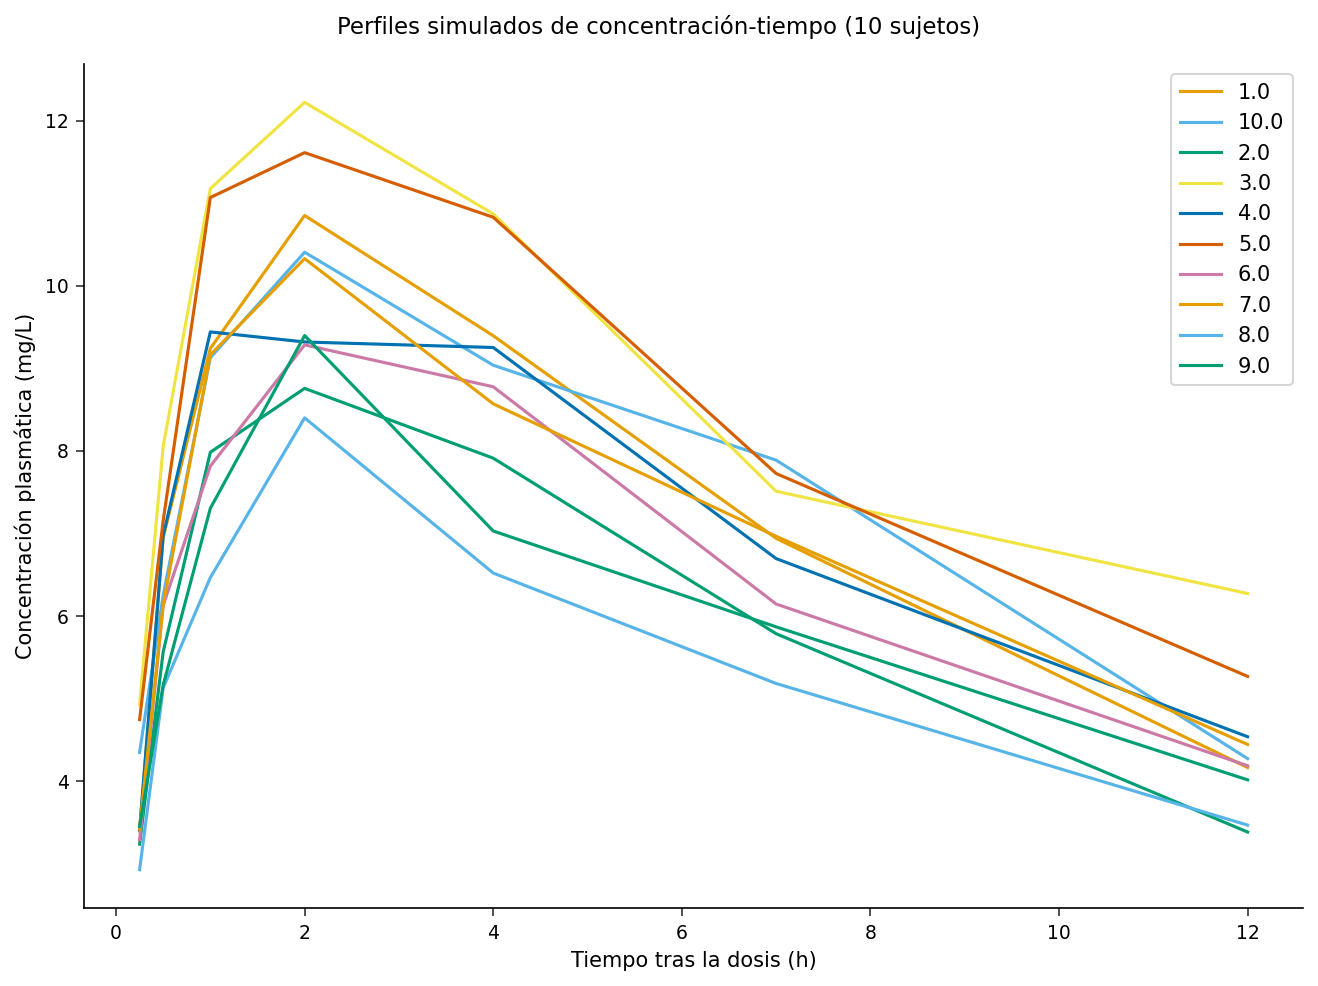

In [3]:
ODS GRAPHICS ON;
PROCEDIMIENTO SGPLOT DATOS=pk;
    SERIES x=time y=conc / GROUP=subject MARKERS
           LINEATTRS=(pattern=solid);
    XAXIS ETIQUETA='Tiempo tras la dosis (h)';
    YAXIS ETIQUETA='Concentración plasmática (mg/L)';
    TÍTULO 'Perfiles simulados de concentración-tiempo (10 sujetos)';
EJECUTAR;
ODS GRAPHICS OFF;
TÍTULO;

## 4. Ajustar el modelo FC poblacional con PROC NLMIXED

PROC NLMIXED maximiza la verosimilitud marginal, integrando sobre el efecto aleatorio mediante cuadratura gaussiana adaptativa. El modelo se construye con sentencias de programación ordinarias entre PARMS y MODEL:

- **PARMS** provee los valores iniciales para los tres efectos fijos (`beta1`-`beta3`), la varianza del efecto aleatorio `s2b1`, y la varianza residual `s2`.
- Las sentencias de asignación reconstruyen el aclaramiento específico del sujeto sumando el efecto aleatorio `b1` (declarado en la sentencia RANDOM) al efecto fijo `beta1`, mantienen la absorción y la eliminación como efectos fijos, y luego evalúan la predicción de un compartimento `pred`.
- **MODEL conc ~ normal(pred, s2)** declara la distribución condicional de la respuesta dado el efecto aleatorio.
- **RANDOM b1 ~ normal(0, s2b1) subject=subject** especifica una distribución normal para la desviación a nivel de sujeto en el log-aclaramiento.

La opción `COV` solicita la matriz de covarianza aproximada de las estimaciones de los parámetros, de la cual se derivan los errores estándar.

In [4]:
PROCEDIMIENTO nlmixed DATOS=pk COV;
    parms beta1=-3.2 beta2=0.45 beta3=-2.45
          s2b1=0.05 s2=0.16;

    /* Aclaramiento específico del sujeto (el enlace log lo mantiene positivo) */
    cl = exp(beta1 + b1);
    ka = exp(beta2);
    ke = exp(beta3);

    /* Predicción de un compartimento con absorción de primer orden */
    pred = dose * ke * ka *
           (exp(-ke*time) - exp(-ka*time)) / cl / (ka - ke);

    MODELO conc ~ normal(pred, s2);
    RANDOM b1 ~ normal(0, s2b1) SUBJECT=subject;

    ETIQUETA conc='Concentración plasmática (mg/L)' subject='Sujeto'
             time='Tiempo tras la dosis (h)' dose='Dosis (mg/kg)' wt='Peso corporal (kg)';

    TÍTULO 'Modelo FC poblacional: un compartimento, absorción de primer orden';
EJECUTAR;
TÍTULO;


                         The NLMIXED Procedure
                         PROC NLMIXED

    Alpha= 0.0500

                           Specifications

    Dependent Variable             Concentración plasmática (mg/L)
    Distribution for Dependent Variable Normal
    Random Effects                 B1
    Distribution for Random Effects Normal
    Subject Variable               Sujeto
    Optimization Technique         
    Integration Method             Gauss-Hermite

                             Dimensions

    Observations Used                        70
    Subjects                                 10
    Max Obs Per Subject                      7
    Parameters                               5
    Quadrature Points                        

                          Fit Statistics

    Description                                     Value
    ---------------------------------------- ------------
    -2 Log Likelihood                               109.9
    AIC (smaller is better)       


NOTE: PROC NLMIXED data=pk

NOTE: Using nlmixed_renderer.py wrapper
NOTE: PROC NLMIXED completed.


## 5. Retransformar a magnitudes farmacocinéticas interpretables

Los efectos fijos se estiman en la escala logarítmica, así que usamos sentencias ESTIMATE para recuperar los parámetros poblacionales (del sujeto típico) en su escala natural. A partir de las constantes de tasa derivamos la vida media de eliminación $t_{1/2} = \ln 2 / k_e$ (horas), y también reportamos la desviación estándar entre sujetos en el aclaramiento, $\sqrt{s^2_{b1}}$. Cada ESTIMATE es una función diferenciable de los parámetros del modelo; PROC NLMIXED reporta el valor puntual, y para la transformación del componente de varianza también propaga un error estándar por el método delta.

In [5]:
PROCEDIMIENTO nlmixed DATOS=pk COV;
    parms beta1=-3.2 beta2=0.45 beta3=-2.45
          s2b1=0.05 s2=0.16;

    cl = exp(beta1 + b1);
    ka = exp(beta2);
    ke = exp(beta3);
    pred = dose * ke * ka *
           (exp(-ke*time) - exp(-ka*time)) / cl / (ka - ke);

    MODELO conc ~ normal(pred, s2);
    RANDOM b1 ~ normal(0, s2b1) SUBJECT=subject;

    ETIQUETA conc='Concentración plasmática (mg/L)' subject='Sujeto'
             time='Tiempo tras la dosis (h)' dose='Dosis (mg/kg)' wt='Peso corporal (kg)';

    /* Parámetros FC poblacionales (sujeto típico) */
    ESTIMACIÓN 'Aclaramiento  CL/F (L/h)' exp(beta1);
    ESTIMACIÓN 'Absorción ka (1/h)'       exp(beta2);
    ESTIMACIÓN 'Eliminación ke (1/h)'     exp(beta3);
    ESTIMACIÓN 'Vida media  t1/2 (h)'     log(2) / exp(beta3);
    ESTIMACIÓN 'VES en CL (DE)'           sqrt(s2b1);

    TÍTULO 'Parámetros FC poblacionales retransformados';
EJECUTAR;
TÍTULO;


                         The NLMIXED Procedure
                         PROC NLMIXED

    Alpha= 0.0500

                           Specifications

    Dependent Variable             Concentración plasmática (mg/L)
    Distribution for Dependent Variable Normal
    Random Effects                 B1
    Distribution for Random Effects Normal
    Subject Variable               Sujeto
    Optimization Technique         
    Integration Method             Gauss-Hermite

                             Dimensions

    Observations Used                        70
    Subjects                                 10
    Max Obs Per Subject                      7
    Parameters                               5
    Quadrature Points                        

                          Fit Statistics

    Description                                     Value
    ---------------------------------------- ------------
    -2 Log Likelihood                               109.9
    AIC (smaller is better)       


NOTE: PROC NLMIXED data=pk

NOTE: Using nlmixed_renderer.py wrapper
NOTE: PROC NLMIXED completed.


## 6. Concentraciones observadas versus predichas a nivel poblacional

Para verificar que el modelo estructural capta ambas fases de la curva de concentración-tiempo, evaluamos la predicción del sujeto típico en cada observación usando las estimaciones poblacionales ajustadas y la comparamos con la concentración observada. Volvemos a introducir las estimaciones de efectos fijos en escala logarítmica de la Sección 4 en la ecuación de un compartimento dentro de un DATA step, y luego resumimos los residuales. Una media residual cercana a cero sin tendencia sistemática indica que el modelo poblacional está bien especificado; la dispersión restante refleja la variabilidad entre sujetos en el aclaramiento más el error de medición.

In [6]:
DATOS fit;
    ESTABLECER pk;
    /* Estimaciones poblacionales (sujeto típico) ajustadas, de la
       tabla de Estimaciones de Parámetros de PROC NLMIXED en la Sección 4 */
    cl_hat = exp(-3.2338);
    ka_hat = exp( 0.4494);
    ke_hat = exp(-2.4213);
    pred   = dose * ke_hat * ka_hat *
             (exp(-ke_hat*time) - exp(-ka_hat*time))
             / cl_hat / (ka_hat - ke_hat);
    resid  = conc - pred;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=fit(obs=7) noobs;
    VAR subject time conc pred resid;
    ETIQUETA subject='Sujeto' time='Tiempo tras la dosis (h)' conc='Concentración observada (mg/L)'
             pred='Concentración predicha (mg/L)' resid='Residual';
    TÍTULO 'Concentración observada vs. predicha a nivel poblacional (sujeto 1)';
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=fit n mean std MIN MAX maxdec=3;
    VAR resid;
    ETIQUETA resid='Residual';
    TÍTULO 'Resumen de residuales (observado menos predicción poblacional)';
EJECUTAR;
TÍTULO;

                          Concentración observada vs. predicha a nivel poblacional (sujeto 1)                           

Sujeto  Tiempo tras la dosis (h)   Concentración observada (mg/L)   Concentración predicha (mg/L)       Residual
     1                      0.25                     3.3987945617                    4.3247809833  -0.9259864216
     1                       0.5                     6.9527160709                    7.1525537855  -0.1998377147
     1                         1                     9.2408905877                   10.1086176706  -0.8677270829
     1                         2                    10.8511932403                   11.3582018932   -0.507008653
     1                         4                     9.3953197218                   10.0040543287   -0.608734607
     1                         7                     6.9421703537                    7.6848009256  -0.7426305719
     1                        12                     4.1674816348                    4.


NOTE: DATA fit


NOTE: Read 70 rows from pk.
NOTE: Wrote fit (70 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=fit

NOTE: PROC PRINT completed: 7 observations printed, 5 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 7. Interpretación de los resultados

El modelo ajustado recupera la farmacocinética poblacional usada para simular el estudio. La tabla de **Estimaciones de Parámetros** reporta los efectos fijos en escala logarítmica con sus errores estándar: log-aclaramiento cercano a $-3.23$, log-absorción cercano a $0.45$, y log-eliminación cercano a $-2.42$, todos próximos a los valores que generaron los datos ($-3.22$, $0.47$, $-2.45$) y cada uno estimado con un error estándar pequeño. La tabla de **Estimaciones Adicionales** retransforma estos valores en las magnitudes que un farmacólogo reporta: un aclaramiento aparente típico de aproximadamente $0.039$ L/h, una constante de tasa de absorción cercana a $1.57$ 1/h, y una vida media de eliminación de aproximadamente $7.8$ horas. El componente de varianza `s2b1` (aproximadamente $0.028$, una DE entre sujetos de $0.17$ en la escala logarítmica) cuantifica cuánto varía el aclaramiento de un sujeto a otro — el efecto aleatorio que impulsa la dispersión vertical observada en el gráfico de perfiles.

La comparación entre lo observado y lo predicho confirma que el modelo estructural sigue tanto la fase ascendente (absorción) como la descendente (eliminación): los residuales están centrados cerca de cero sin curvatura sistemática. Modelar el aclaramiento como el único efecto aleatorio entre sujetos mantiene la verosimilitud marginal bien condicionada mientras capta la principal fuente de variabilidad farmacocinética. En la práctica, los siguientes pasos serían agregar una covariable de peso corporal o función renal al submodelo de aclaramiento, probar si la absorción también amerita un efecto aleatorio, comparar estructuras de uno versus dos compartimentos mediante AIC/BIC, y ejecutar diagnósticos basados en simulación (verificaciones predictivas visuales) antes de usar el modelo para recomendaciones de dosis.